# 10 — Diagnostics, simulation, validation evidence, interchange, and archives

This end-to-end notebook fits a small longitudinal LMM and then exercises the supported post-fit workflow: residual diagnostics, seeded simulation, VPC data, versioned result archives with integrity checks, deterministic validation bundles, and conservative interchange reports.

## Objectives

- Fit a reproducible reference LMM used by later sections.
- Create residual and simulation-based diagnostic tables.
- Save and verify a non-pickle result archive.
- Create and verify a context-supporting validation evidence bundle.
- Use supported NONMEM-data, R-formula, and SED-ML interchange subsets.
- Read compatibility reports and integrity claims conservatively.

In [1]:
import logging
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np

import pymixef
from pymixef.interoperability import (
    export_sedml,
    import_nonmem_data,
    import_sedml,
)
from pymixef.interoperability.r import translate_r_formula

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt  # noqa: E402

SEED = 20260710
rng = np.random.default_rng(SEED)
PLOT_COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "black": "#222222",
}

## Fit a small reproducible model

Ten synthetic subjects contribute four measurements each. The fitted object archives calculation metadata needed by the supported Gaussian simulation fallback.

In [2]:
subject_index = np.repeat(np.arange(10), 4)
time = np.tile(np.arange(4, dtype=float), 10)
random_intercept = rng.normal(0.0, 0.6, 10)
y = 2.0 + 0.5 * time + random_intercept[subject_index] + rng.normal(0.0, 0.3, len(time))
data = {
    "y": y,
    "time": time,
    "subject": np.array([f"S{i + 1:02d}" for i in subject_index]),
}

fit = pymixef.fit(
    "y ~ time + (1 | subject)",
    data=data,
    method="reml",
    maxiter=300,
    compute_hessian=False,
)
print(fit.summary())

PyMixEF fit (lmm, reml)
Observations: 40
Objective: 15.24635499
Log likelihood: -15.24635499
Convergence: converged
Parameters:
  Intercept               1.3139967
  time                    0.52977799
  sd(subject:Intercept)   0.37649945
  residual_sd             0.24842785


## Residual diagnostics

Diagnostic tables retain aligned row identifiers and machine-readable columns. They are data for analysis and plotting; no single scalar certifies adequate fit.

In [3]:
residuals = fit.residual_diagnostics()
raw = residuals.columns["raw_residual"]
{
    "diagnostic_name": residuals.name,
    "columns": list(residuals.columns),
    "rows": len(residuals),
    "mean_raw_residual": float(np.mean(raw)),
    "raw_residual_rmse": float(np.sqrt(np.mean(raw**2))),
}

{'diagnostic_name': 'residuals',
 'columns': ['row_id',
  'observed',
  'fitted',
  'raw_residual',
  'pearson_residual'],
 'rows': 40,
 'mean_raw_residual': -2.7755575615628915e-18,
 'raw_residual_rmse': 0.2147265492857147}

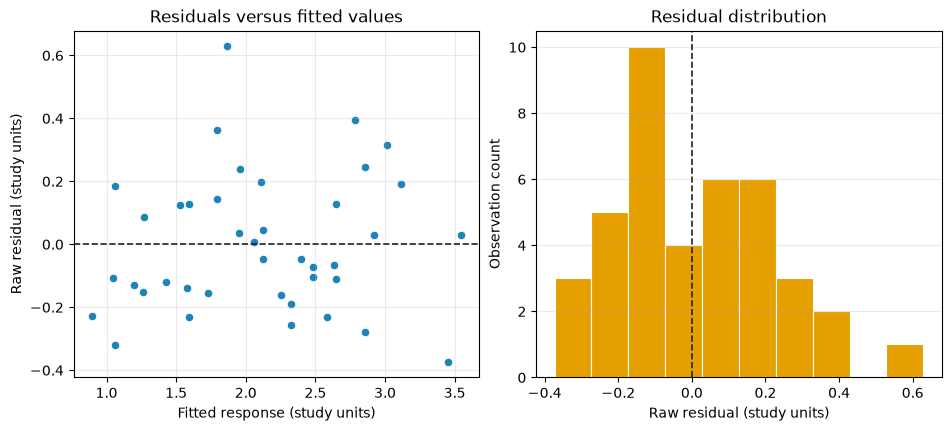

In [4]:
fitted_values = np.asarray(residuals.columns["fitted"], dtype=float)
fig, (ax_scatter, ax_histogram) = plt.subplots(
    1,
    2,
    figsize=(9.4, 4.2),
    constrained_layout=True,
)
ax_scatter.scatter(
    fitted_values,
    raw,
    color=PLOT_COLORS["blue"],
    edgecolor="white",
    linewidth=0.6,
    alpha=0.88,
)
ax_scatter.axhline(0.0, color=PLOT_COLORS["black"], linestyle="--", linewidth=1.2)
ax_scatter.set_xlabel("Fitted response (study units)")
ax_scatter.set_ylabel("Raw residual (study units)")
ax_scatter.set_title("Residuals versus fitted values")
ax_scatter.grid(alpha=0.25)

ax_histogram.hist(
    raw,
    bins=10,
    color=PLOT_COLORS["orange"],
    edgecolor="white",
    linewidth=0.8,
)
ax_histogram.axvline(0.0, color=PLOT_COLORS["black"], linestyle="--", linewidth=1.2)
ax_histogram.set_xlabel("Raw residual (study units)")
ax_histogram.set_ylabel("Observation count")
ax_histogram.set_title("Residual distribution")
ax_histogram.grid(axis="y", alpha=0.25)
plt.show()

Residuals are centered near zero without a strong fitted-value trend in this small synthetic example. The plot is a prompt for structured review, not proof of normality, constant variance, or external model adequacy.

## Seeded new-replicate simulation and VPC data

For this archived Gaussian LMM, simulation uses the full archived observation covariance. These are new replicate datasets, not repeated fitted values. The VPC helper returns quantile-table data rather than silently choosing a plotting library.

In [5]:
simulations = fit.simulate(n_replicates=100, seed=SEED)
repeat_simulations = fit.simulate(n_replicates=100, seed=SEED)
same_seed = np.array_equal(simulations, repeat_simulations)
assert same_seed, "Seeded simulations must reproduce exactly"
print("Simulation shape:", simulations.shape)
print("Same seed is identical:", same_seed)

vpc = fit.vpc(bins=3, simulations=100, seed=SEED)
print("VPC columns:", list(vpc.columns))
print("VPC rows:", len(vpc))

Simulation shape: (100, 40)
Same seed is identical: True
VPC columns: ['bin', 'bin_left', 'bin_right', 'quantile', 'observed', 'simulated_median', 'simulated_lower', 'simulated_upper', 'n_observed']
VPC rows: 9


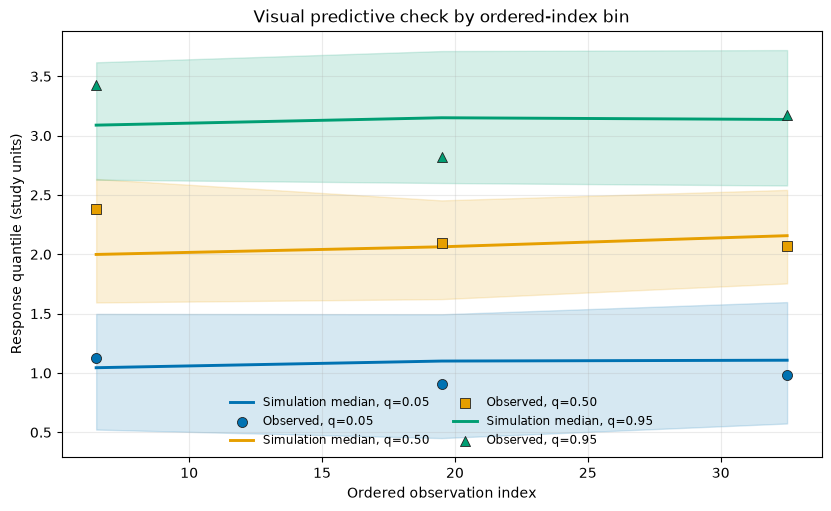

In [6]:
vpc_columns = vpc.columns
quantile_colors = {
    0.05: PLOT_COLORS["blue"],
    0.50: PLOT_COLORS["orange"],
    0.95: PLOT_COLORS["green"],
}
quantile_markers = {0.05: "o", 0.50: "s", 0.95: "^"}

fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
for quantile in np.unique(vpc_columns["quantile"]):
    quantile_value = float(quantile)
    mask = np.isclose(vpc_columns["quantile"], quantile_value)
    bin_centers = (vpc_columns["bin_left"][mask] + vpc_columns["bin_right"][mask]) / 2.0
    color = quantile_colors[quantile_value]
    ax.fill_between(
        bin_centers,
        vpc_columns["simulated_lower"][mask],
        vpc_columns["simulated_upper"][mask],
        color=color,
        alpha=0.16,
    )
    ax.plot(
        bin_centers,
        vpc_columns["simulated_median"][mask],
        color=color,
        linewidth=2.1,
        label=f"Simulation median, q={quantile_value:.2f}",
    )
    ax.scatter(
        bin_centers,
        vpc_columns["observed"][mask],
        color=color,
        edgecolor=PLOT_COLORS["black"],
        linewidth=0.6,
        marker=quantile_markers[quantile_value],
        s=52,
        label=f"Observed, q={quantile_value:.2f}",
        zorder=3,
    )
ax.set_xlabel("Ordered observation index")
ax.set_ylabel("Response quantile (study units)")
ax.set_title("Visual predictive check by ordered-index bin")
ax.legend(frameon=False, ncol=2, fontsize=8.5)
ax.grid(alpha=0.25)
plt.show()

Observed 5th, 50th, and 95th percentile markers are compared with seeded simulation medians and envelopes in each ordered-index bin. Here the observed markers remain inside the envelopes, a useful visual calibration check rather than a formal acceptance criterion.

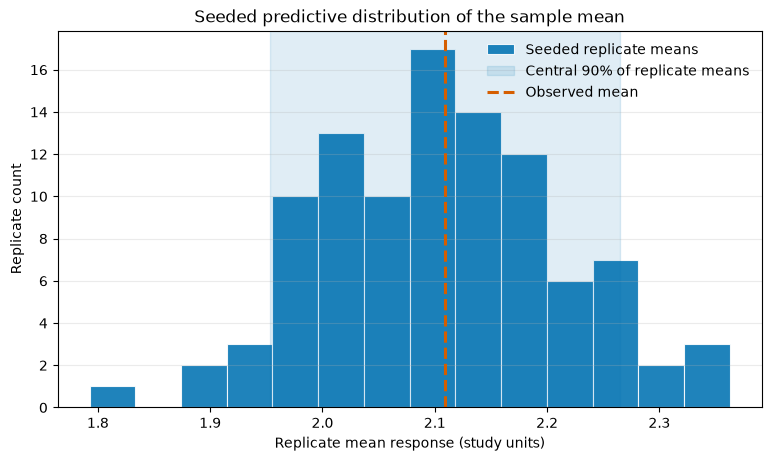

In [7]:
simulated_means = np.mean(simulations, axis=1)
observed_mean = float(np.mean(y))
mean_interval = np.quantile(simulated_means, [0.05, 0.95])

fig, ax = plt.subplots(figsize=(7.6, 4.5), constrained_layout=True)
ax.hist(
    simulated_means,
    bins=14,
    color=PLOT_COLORS["blue"],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.88,
    label="Seeded replicate means",
)
ax.axvspan(
    mean_interval[0],
    mean_interval[1],
    color=PLOT_COLORS["blue"],
    alpha=0.12,
    label="Central 90% of replicate means",
)
ax.axvline(
    observed_mean,
    color=PLOT_COLORS["vermillion"],
    linewidth=2.2,
    linestyle="--",
    label="Observed mean",
)
ax.set_xlabel("Replicate mean response (study units)")
ax.set_ylabel("Replicate count")
ax.set_title("Seeded predictive distribution of the sample mean")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.show()

Replicate means vary because each simulation draws a new longitudinal dataset from the archived Gaussian covariance. Comparing the observed mean with this seeded reference distribution illustrates one predictive summary without replacing subject-level or residual diagnostics.

## Versioned result archive

PyMixEF saves JSON rather than pickle and writes a whole-file SHA-256 sidecar. Loading with `require_sidecar=True` verifies that sidecar, manifest output hashes, and the manifest's semantic ModelIR hash.

In [8]:
temporary_workspace = TemporaryDirectory()
artifact_dir = Path(temporary_workspace.name)

result_path = fit.save(artifact_dir / "fit.json")
reloaded = pymixef.FitResult.load(result_path, require_sidecar=True)

{
    "result_exists": result_path.exists(),
    "sidecar_exists": result_path.with_suffix(".json.sha256").exists(),
    "parameters_preserved": reloaded.parameters == fit.parameters,
    "model_ir_hash": reloaded.manifest.model_ir_hash,
}

{'result_exists': True,
 'sidecar_exists': True,
 'parameters_preserved': True,
 'model_ir_hash': 'sha256:994469709cdb83a52fc456801afd8805dd7c48f4af9d5cc64833c5ab26f4aad5'}

## Validation evidence bundle

The bundle includes the result, manifest, traceability snapshot, explanatory README, and internal hashes. Raw analysis data are excluded by default. A valid bundle supports a context-specific validation process; it is not a universal regulatory certificate.

In [9]:
bundle_path = pymixef.create_validation_bundle(
    fit,
    artifact_dir / "validation-bundle.zip",
    analysis_data=data,
    include_data=False,
)
bundle_check = pymixef.verify_validation_bundle(bundle_path)
assert bundle_check["valid"]
{
    "valid": bundle_check["valid"],
    "files": bundle_check["files"],
    "engine": bundle_check["manifest"]["engine"],
    "data_hash": bundle_check["manifest"]["data_hash"],
}

{'valid': True,
 'files': ['README.txt', 'manifest.json', 'result.json', 'traceability.json'],
 'engine': 'lmm',
 'data_hash': 'sha256:3a33c9ef1ebf788ea3cd4ac68c5941dfb0642be511f5392b345a91c17a1bedb3'}

## Conservative interchange subsets

Every translation returns a value plus a compatibility report. Call `require_supported()` only after reviewing that report. The examples below stay within supported subsets: standard NONMEM-style data names, a formula requiring no external R evaluation, and a uniform-timecourse SED-ML design.

In [10]:
nonmem_data = import_nonmem_data({"id": [1, 1], "time": [0, 1], "dv": [2.0, 1.5]})
formula_translation = translate_r_formula("y ~ time + (1 | subject)")

sedml_path = artifact_dir / "design.xml"
sedml_export = export_sedml(
    {"output_end_time": 24.0, "number_of_points": 24},
    sedml_path,
)
sedml_design = import_sedml(sedml_path).require_supported()
assert nonmem_data.report.supported
assert formula_translation.report.supported
assert sedml_export.report.supported

{
    "NONMEM data supported": nonmem_data.report.supported,
    "R formula supported": formula_translation.report.supported,
    "SED-ML export supported": sedml_export.report.supported,
    "SED-ML simulation": sedml_design["simulations"][0],
}

{'NONMEM data supported': True,
 'R formula supported': True,
 'SED-ML export supported': True,
 'SED-ML simulation': {'id': 'simulation',
  'initial_time': 0.0,
  'output_start_time': 0.0,
  'output_end_time': 24.0,
  'number_of_points': 24,
  'algorithm': 'KISAO:0000019'}}

A formula requiring R's `poly()` evaluator is refused because PyMixEF will not execute arbitrary R code or guess at its generated basis.

In [11]:
unsupported_formula = translate_r_formula("y ~ poly(time, 2) + (1 | subject)")
{
    "supported": unsupported_formula.report.supported,
    "unsupported_issues": [
        issue.to_dict() for issue in unsupported_formula.report.by_status("unsupported")
    ],
}

{'supported': False,
 'unsupported_issues': [{'construct': 'poly(',
   'status': 'unsupported',
   'message': 'R environment/function evaluation is not executed by PyMixEF; create the transformed column explicitly.',
   'source_location': None}]}

In [12]:
# Explicit cleanup keeps the tutorial self-contained.
temporary_workspace.cleanup()

## Scope note

These tools strengthen an evidence workflow: diagnostics inform review, hashes detect inconsistent artifacts, bundles preserve context, and compatibility reports make interchange decisions explicit. Their implementation limitations are intentionally visible—hashes are not signatures, bundles are not universal regulatory certificates, and unsupported portable simulation or interchange semantics are refused.

## Exercises

1. Change the simulation seed and compare reproducibility within and across seeds.
2. Save a result, alter a copy of its JSON, and confirm that loading the copy fails integrity verification.
3. Include synthetic analysis data in a bundle and inspect its member list; never do this with sensitive data without authorization.
4. Add an unsupported construct to an interchange example and practice reporting the refusal rather than bypassing it.